In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from random import randint
from random import random
import math
import csv

In [3]:
#Generate Grid with random edge lengths
def GenGrid(l,w,r):
    Grid = [[0 for k in range(l*w)] for y in range(l*w)]
    for i in range(l*w):
        for j in range(w*l):
            if Grid[j][i] != 0:
                Grid[i][j] = Grid[j][i]
            else:
                if ((j == i - 1) or (j == i + 1) or (j == i + w) or (j == i - w)):
                    Grid[i][j] = round((r[1]-r[0]) * random() + r[0],2)
                if ((i+1)%w == 0 and j == i + 1) or (i%w == 0 and j == i - 1):
                    Grid[i][j] = 0
    return Grid
            

In [4]:
def GenMap(f):
    Edges = [[],[],[]]
    Lines = []
    for i in f:
        Lines.append(i[0:-1])
    for i in range(2):
        for j in range(len(Lines)-1):
            if Lines[j][1] == ' ':
                Edges[i].append(int(Lines[j][0]))
                Lines[j] = Lines[j][2:]
            else:
                Edges[i].append(int(Lines[j][0:2]))
                Lines[j] = Lines[j][3:]
    for j in Lines[0:-1]:
        if len(j) == 1:
            Edges[2].append(int(j[0]))
        else:
            Edges[2].append(int(j[0:2]))
    Grid = [[0 for i in range(len(Edges[0]))] for j in range(len(Edges[0]))]
    for i in range(len(Edges[0])):
        Val1 = Edges[0][i]
        Val2 = Edges[1][i]
        Grid[Val1][Val2] = Edges[2][i]
        Grid[Val2][Val1] = Edges[2][i]
    return Grid

In [5]:
def VisualiseGraph(adj_matrix, path=None):
    G = nx.Graph()
    n = len(adj_matrix)

    # Build base graph
    for i in range(n):
        for j in range(i + 1, n):
            if adj_matrix[i][j] != 0:
                G.add_edge(i, j, weight=adj_matrix[i][j])

    pinned_node = path[0] if path and len(path) > 0 else 0

    pos = nx.kamada_kawai_layout(G)

    nx.draw(
        G,
        pos,
        node_color="skyblue",
        with_labels=True,
        node_size=300,
        font_size=12,
        edge_color="gray")

    edge_labels = nx.get_edge_attributes(G, 'weight')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path is not None and len(path) > 1:
        path_edges = list(zip(path, path[1:]))

        DG = nx.DiGraph()
        DG.add_edges_from(path_edges)

        nx.draw_networkx_edges(
            DG,
            pos,
            edge_color="red",
            width=3,
            arrows=True,
            arrowstyle='-|>',
            arrowsize=20
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=path,
            node_color="orange",
            node_size=300
        )

    plt.show()

In [6]:
def FixedDemand(l,w, D):
    Passenger = [D]
    return Passenger * l * w

In [7]:
def NearestNode(distances, CheckedNode):
    best = [0,9999]
    for i in distances:
        if i not in CheckedNode and distances[i] < best[1]:
            best = [i,distances[i]]
    return best

In [8]:
def CheckNeighbours(adj_matrix,path,Stops,Node,CheckedNode,distances):
    
    CheckedNode.append(Node[0])   
    if Node[0] in path:
        Stops.append(Node[0])
    
    for i in range(len(adj_matrix)):
        dist = adj_matrix[Node[0]][i]
        if dist != 0 and not i in CheckedNode:
            if i in distances:
                if Node[1] + dist < distances[i]:
                    distances[i] = Node[1] + dist
            else:
                distances[i] = Node[1] + dist
    return distances, Stops, CheckedNode

In [9]:
def NearestStop(adj_matrix,path,Node,k2,k3):
    if Node in path:
        return Node, 0
    CheckedNode = []
    distances = {Node : 0}
    Stops = []
    while len(Stops) < len(path):
        Nearest = NearestNode(distances,CheckedNode)
        distances, Stops, CheckedNode = CheckNeighbours(adj_matrix, path, Stops, Nearest, CheckedNode, distances)

    #Bus distance calc
    BusDis = [0]
    for i in range(len(path)-1):
        BusDis.insert(0,adj_matrix[path[-(i+1)]][path[-i-2]] + BusDis[0])
    
    pathcost = []
    for i in path:
        pathcosti = k2 * distances[i] + k3 * BusDis[path.index(i)]
        pathcost.append(pathcosti)
    cost = min(pathcost)
    EndStop = path[pathcost.index(cost)]
    cost = k2 * distances[EndStop]
    return EndStop, cost

In [10]:
def BusTimetable(adj_matrix,path,k4,k5,headway,n):
    Buses = int(n/headway) + 1
    Timetable = [{0 + i*headway :path[0]} for i in range(Buses)]
    time = 0
    for i in range(1,len(path)):
        time += k5 + int(adj_matrix[path[i]][path[i-1]] / k4) + 1
        for j in range(Buses):
            Timetable[j][time +  + j * headway] = path[i]
    
    return Timetable

In [11]:
def GenSeed(adj_matrix,n,SpawnDensity):
    Seed = [[],[],[]]         #Stop, Time, Quantity
    for i in range(len(SpawnDensity)):
        Cumul = 0
        for j in range(n):
            Cumul += SpawnDensity[i]/60
            if Cumul >= 1:
                Seed[0].append(i)
                Seed[1].append(j)
                Seed[2].append(int(Cumul))
                Cumul -= int(Cumul)
    return Seed

In [12]:
def Loading(adj_matrix,path,k2,k3,headway,n,SpawnDensity):
    
    StopData = [[i for i in range(len(adj_matrix))], [NearestStop(adj_matrix,path,j,k2,k3) for j in range(len(adj_matrix))]]
    Timetable = BusTimetable(adj_matrix,path,k4,k5,headway,n)
    Seed = GenSeed(adj_matrix,n,SpawnDensity)

    return StopData, Timetable, Seed

In [13]:
def RunRoute(adj_matrix,path,StopData,Timetable,Seed,headway,BusCap,Time):
    PassengerStops = [path,[0 for i in range(len(path))]]
    PassengerTimes = [[],[],[],[]]     #Stop, Time, Quantity, Start Time

    Locations = [[i for i in range(len(adj_matrix))],[0 for j in range(len(adj_matrix))]]
    
    BusLoad = [0 for i in range(len(Timetable))]
    WalkTime = 0
    WaitTime = 0
    BusWaitTime = 0
    for t in range(Time):
        
        #Spawn in new passengers
        if t in Seed[1]:
            for i in range(len(Seed[0])):
                if t == Seed[1][i]:
                    Locations[1][Seed[0][i]] += Seed[2][i]
        
        #Move passengers from their start points onto passengertimes:
        if max(Locations[1]) > 0:
            for i in range(len(Locations[0])):
                if Locations[1][i] > 0:
                    NearStop = StopData[1][i]
                    PassengerTimes[0].append(NearStop[0])
                    if NearStop[1] == 0:
                        PassengerTimes[1].append(t)
                    else:
                        PassengerTimes[1].append(math.ceil((t + NearStop[1])/k6))
                        WalkTime += math.ceil(NearStop[1]/k6)
                    PassengerTimes[2].append(Locations[1][i])
                    Locations[1][i] = 0

        #Passengers reach the bus stops
        if t in PassengerTimes[1]:
            for i in range(len(PassengerTimes[1])):
                if PassengerTimes[1][i] == t:
                    StopIndex = path.index(PassengerTimes[0][i])
                    PassengerStops[1][StopIndex] += PassengerTimes[2][i]
                    for j in range(t,n):
                        for k in range(len(Timetable)):
                            if j in Timetable[k]:
                                if Timetable[k][j] == PassengerTimes[0][i]:
                                    WaitTime += PassengerTimes[2][i] * (j - t)
                                    break
                        else:
                            continue
                        break
                        

        #Bus picks up the passengers
        for i in Timetable:
            if t in i.keys():
                Index1 = i[t]
                Index2 = PassengerStops[0].index(Index1)
                BusWaitTime += PassengerStops[1][Index2] * (max(i) - t)
                if BusLoad[Timetable.index(i)] + PassengerStops[1][Index2] >= BusCap:
                    Space = BusCap - BusLoad[Timetable.index(i)]
                    BusLoad[Timetable.index(i)] = BusCap
                    PassengerStops[1][Index2] -= Space
                    WaitTime += PassengerStops[1][Index2] * headway
                else:
                    BusLoad[Timetable.index(i)] += PassengerStops[1][Index2]
                    PassengerStops[1][Index2] = 0
    #Bus cost calc
    BusTime = 0
    for i in Timetable:
        if max(i) < n:
            BusTime += max(Timetable[0])
        else:
            BusTime += n - min(i)

    print('Individual Costs \n',
          'Walk Cost',k2 * WalkTime, '\n',
          'Wait Time Cost',k2 * WaitTime, '\n',
          'Bus Wait Time Cost',k3 * BusWaitTime, '\n',
          'Bus Cost', k1 * BusTime, '\n'
         'Total Cost', k2 * (WalkTime + WaitTime) + k3 * BusWaitTime + k1 * BusTime )
    print(BusLoad)

In [14]:
def SilentRunRoute(adj_matrix,path,StopData,Timetable,Seed,headway,BusCap,Time):
    PassengerStops = [path,[0 for i in range(len(path))]]
    PassengerTimes = [[],[],[]]     #Stop, Time, Quantity

    Locations = [[i for i in range(len(adj_matrix))],[0 for j in range(len(adj_matrix))]]
    
    BusLoad = [0 for i in range(len(Timetable))]
    WalkTime = 0
    WaitTime = 0
    BusWaitTime = 0
    for t in range(Time):
        
        #Spawn in new passengers
        if t in Seed[1]:
            for i in range(len(Seed[0])):
                if t == Seed[1][i]:
                    Locations[1][Seed[0][i]] += Seed[2][i]
        
        
        #Move passengers from their start points onto passengertimes:
        if max(Locations[1]) > 0:
            for i in range(len(Locations[0])):
                if Locations[1][i] > 0:
                    NearStop = StopData[1][i]
                    PassengerTimes[0].append(NearStop[0])
                    if NearStop[1] == 0:
                        PassengerTimes[1].append(t)
                    else:
                        PassengerTimes[1].append(math.ceil((t + NearStop[1])/k6))
                        WalkTime += math.ceil(NearStop[1]/k6)
                    PassengerTimes[2].append(Locations[1][i])
                    Locations[1][i] = 0

        #Passengers reach the bus stops
        if t in PassengerTimes[1]:
            for i in range(len(PassengerTimes[1])):
                if PassengerTimes[1][i] == t:
                    StopIndex = path.index(PassengerTimes[0][i])
                    PassengerStops[1][StopIndex] += PassengerTimes[2][i]
                    for j in range(t,n):
                        for k in range(len(Timetable)):
                            if j in Timetable[k]:
                                if Timetable[k][j] == PassengerTimes[0][i]:
                                    WaitTime += PassengerTimes[2][i] * (j - t)
                                    break
                        else:
                            continue
                        break
                        

        #Bus picks up the passengers
        for i in Timetable:
            if t in i.keys():
                Index1 = i[t]
                Index2 = PassengerStops[0].index(Index1)
                if BusLoad[Timetable.index(i)] + PassengerStops[1][Index2] >= BusCap:
                    Space = BusCap - BusLoad[Timetable.index(i)]
                    BusWaitTime += Space * (max(i) - t)
                    BusLoad[Timetable.index(i)] = BusCap
                    PassengerStops[1][Index2] -= Space
                    WaitTime += PassengerStops[1][Index2] * headway

                else:
                    BusWaitTime += PassengerStops[1][Index2] * (max(i) - t)
                    BusLoad[Timetable.index(i)] += PassengerStops[1][Index2]
                    PassengerStops[1][Index2] = 0

    #Bus cost calc
    BusTime = 0
    for i in Timetable:
        if max(i) < n:
            BusTime += max(Timetable[0])
        else:
            BusTime += n - min(i)

    TotalCost = k2 * (WalkTime + WaitTime) + k3 * BusWaitTime + k1 * BusTime
    return round(TotalCost,2), round(BusTime * k1,2), round(k2 * (WalkTime + WaitTime) + k3 * BusWaitTime,2)

In [15]:
def OptHeadway(adj_matrix,path,StopData,Timetable,Seed,BusCap,Time,Range):
    TotalCosts = []
    BusCosts = []
    PassengerCosts = []
    for i in range(Range[0],Range[1]):
        StopData, Timetable,Seed = Loading(adj_matrix,path,k2,k3,i,n,SpawnDensity)
        Total, Bus, Passenger = SilentRunRoute(adj_matrix,path,StopData,Timetable,Seed,i,BusCap,n)
        TotalCosts.append(Total)
        BusCosts.append(Bus)
        PassengerCosts.append(Passenger)
    Min = min(TotalCosts)
    with open("costs.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Index", "TotalCosts", "BusCosts", "PassengerCosts"])
        for i, row in enumerate(zip(TotalCosts, BusCosts, PassengerCosts), start=Range[0]):
            writer.writerow([i, *row])
                   
    OptHeadway = TotalCosts.index(Min) + Range[0]
    return (OptHeadway, Min)

In [16]:
def FindNeighbours2(adj_matrix, Node, Checked):
    Neighbours = []
    for i in range(len(adj_matrix)):
        if adj_matrix[Node][i] != 0 and not i in Checked:
            Neighbours.append(i)
    return Neighbours

In [17]:
def MutualNeighbours(adj_matrix, Node1, Node2):
    Neigh1 = FindNeighbours2(adj_matrix, Node1, [])
    Neigh2 = FindNeighbours2(adj_matrix, Node2, [])
    Mutual = []
    for i in Neigh1:
        for j in Neigh2:
            if i == j:
                Mutual.append(i)
    return Mutual

In [18]:
def Annealing(adj_matrix,path,pathcost,Checked,total,k1,k2,k3):
    if path in Checked:
        Costs = [[],[]]
    else:
        Costs = [[path],[pathcost]]
    for i in range(len(path)-2):
        Mutuals = MutualNeighbours(adj_matrix, path[i], path[i+2])
        for j in Mutuals:
            if not j == path[i+1]:
                TempPath = path[:]
                TempPath[i+1] = j
                if not TempPath in Checked:
                    Costs[0].append(TempPath)
                    StopData, Timetable,Seed = Loading(adj_matrix,TempPath,k2,k3,headway,n,SpawnDensity)
                    A,B,C = SilentRunRoute(adj_matrix,TempPath,StopData,Timetable,Seed,headway,BusCap,n)
                    Costs[1].append(A)
                    total += 1
    
    Route = Costs[0][Costs[1].index(min(Costs[1]))]
    
    return Route,min(Costs[1]), total

In [20]:
def BackwardsSearch3(adj_matrix, k1,k2,k3, Destination):
    Route = [Destination]
    Checked = [Destination]
    
    StopData, Timetable,Seed = Loading(adj_matrix,Route,k2,k3,headway,n,SpawnDensity)
    CurrentCost,Bus,Pass = SilentRunRoute(adj_matrix,Route,StopData,Timetable,Seed,headway,BusCap,n)
    NewCost = CurrentCost - 1
    
    total = 0
    
    while NewCost <= CurrentCost:
        CurrentCost = NewCost
        Neigh = FindNeighbours2(adj_matrix,Route[0],Checked)
        Costs = []
        Options = []
        if Neigh == []:
            break
        for i in range(len(Neigh)):
            NewRoute = Route[:]
            NewRoute.insert(0,Neigh[i])
            total += 1
            StopData, Timetable,Seed = Loading(adj_matrix,NewRoute,k2,k3,headway,n,SpawnDensity)
            NewCost,Bus,Pass = SilentRunRoute(adj_matrix,NewRoute,StopData,Timetable,Seed,headway,BusCap,n)
            Costs.append(NewCost)
            Options.append(NewRoute)
            Checked.append(Neigh[i])

        if CurrentCost < min(Costs):
            break
        else:
            Route = Options[Costs.index(min(Costs))]
            NewCost = min(Costs)
            Checked.append(Route[0])

    Route, Cost, total = Annealing(adj_matrix,Route,CurrentCost,[],total,k1,k2,k3)
    
    print('Total routes checked', total)
    return Route, Cost

In [21]:
def SpecifiedSearch(adj_matrix, destination, Demand): #NOT FUNCTIONAL YET
    Routes = []
    Costs = []
    for i in range(len(adj_matrix)):
        route, cost = SpecifiedStart2(adj_matrix,i,destination,Demand,k1,k2,k3)
        Routes.append(route)
        Costs.append(cost)
    Cost = min(Costs)
    Route = Routes[Costs.index(Cost)]
    Route, Cost, total = Annealing(adj_matrix,Route,Cost,[],0,Demand,k1,k2,k3)
    return Route, Cost


In [23]:
def SpecifiedStart2(adj_matrix,start,destination,Demand,k1,k2,k3):
    if start == destination:
        Cost = TotalCost(adj_matrix,Demand,[start], k1, k2, k3)
        return [start], Cost
    
    CheckedNode = []
    distances = {start : 0}
    Stops = []
    while len(distances) < len(adj_matrix):
        Nearest = NearestNode(distances,CheckedNode)
        distances, Stops, CheckedNode = CheckNeighbours(adj_matrix, [], Stops, Nearest, CheckedNode, distances)
    
    path = [destination]
    for j in range(len(adj_matrix)):
        if path[0] == start:
            break
        Neigh = FindNeighbours2(adj_matrix, path[0], [])
        for i in Neigh:
            dis = distances[path[0]] - adj_matrix[path[0]][i]
            if distances[i] == dis:
                path.insert(0,i)
                break
    
    pathcost = TotalCost(adj_matrix,Demand,path, k1, k2, k3)
    return path,pathcost

In [24]:
l = 5
w = 7
r = [1,1]
D = 1
adj_matrix = GenGrid(l,w,r)

In [25]:
f = open("Map.txt")
Grid = GenMap(f)

In [33]:
k1 = 50/60   #Bus operating cost
k2 = 10/60    #Walk cost (passenger access value)
k3 = 5/60   #Bus travel cost (value of in-vehicle time)
k4 = 20/60    # Bus Speed in km/minute 
k5 = 1     # Stop time in minutes
k6 = 3/60 # Passenger walk speed in km/minute
headway = 10    #Bus headway in minutes
BusCap = 60   #Bus Capacity
n = 600        #Time the simulation runs for

In [28]:
SpawnDensity = [1.5, 9.5, 14.5, 12.75, 11.25, 8.0, 3.0, 5.25, 22.75, 29.0, 24.25, 27.0, 25.75, 11.5, 10.25, 22.0, 21.25, 20.25, 28.75, 35.75, 17.75, 21.0, 25.75, 11.75, 14.5, 19.25, 23.5, 11.75, 14.5, 17.0, 5.0, 5.75, 6.25, 5.5, 2.5]

In [29]:
path = [11,18,25,24, 23, 22, 21]
StopData, Timetable,Seed = Loading(adj_matrix,path,k2,k3,headway,n,SpawnDensity)

In [30]:
RunRoute(adj_matrix,path,StopData,Timetable,Seed,headway,BusCap,n)

Individual Costs 
 Walk Cost 3755.0 
 Wait Time Cost 1283.3333333333333 
 Bus Wait Time Cost 2185.833333333333 
 Bus Cost 1475.0 
Total Cost 8699.166666666666
[33, 25, 26, 30, 27, 24, 27, 28, 30, 28, 28, 28, 27, 28, 28, 30, 25, 26, 30, 27, 31, 31, 28, 28, 27, 26, 26, 31, 26, 24, 30, 31, 29, 27, 27, 27, 28, 27, 27, 30, 29, 30, 28, 26, 28, 29, 31, 28, 26, 27, 27, 30, 26, 25, 28, 30, 31, 22, 16, 9, 0]


In [32]:
Destination = 21
BackwardsSearch3(adj_matrix, k1,k2,k3, Destination)

Total routes checked 15


([25, 24, 23, 22, 21], 7922.67)

In [31]:
Range = [1,40]
OptHeadway(adj_matrix,path,StopData,Timetable,Seed,BusCap,n,Range)

(12, 8686.5)

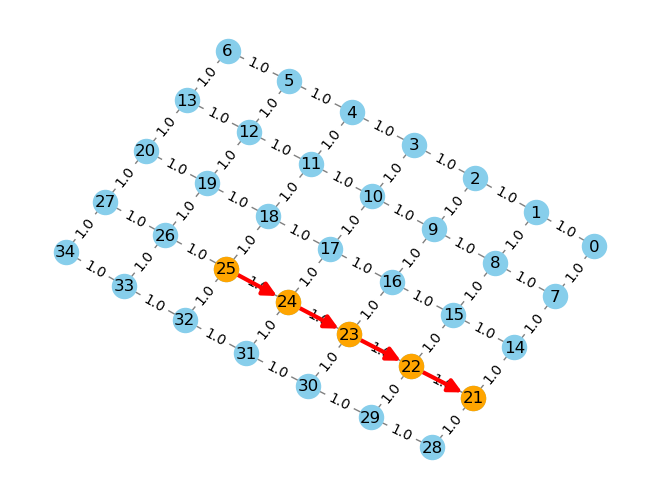

In [62]:
path = [25, 24, 23, 22, 21]
VisualiseGraph(adj_matrix, path)